# Knowledge Graph

In [98]:
import polars as pl
from neo4j import GraphDatabase
from tqdm import tqdm

## Load data

In [100]:
# Load the datasets from Parquet files
df_videos = pl.read_parquet("data/parquet/videos_full_with_topics.parquet")
df_commentthreads = pl.read_parquet("data/parquet/commentThreads_full_with_topics.parquet")
df_commentthreads_replies = pl.read_parquet("data/parquet/commentThreadsReplies_full_with_topics.parquet")

In [ ]:
# Simplify the dataframes by selecting only the necessary columns
df_videos_neo4j = df_videos.select(
    pl.col("videoId"),
    pl.col("topic_level_0").alias("topic"),
    pl.col("emotion"),
    pl.col("entity"),
    pl.col("channelTitle"),
    pl.col("viewCount"),
    pl.col("likeCount"),
    pl.col("commentCount"),
    pl.col("publishedAt"),
    pl.col("duration"),
)

df_commentthreads_neo4j = df_commentthreads.select(
    pl.col("commentThreadId"),
    pl.col("videoId"),
    pl.col("topic_level_0").alias("topic"),
    pl.col("emotion"),
    pl.col("entity"),
    pl.col("authorDisplayName_ct").alias("authorDisplayName"),
    pl.col("likeCount_ct").alias("likeCount"),
    pl.col("totalReplyCount_ct").alias("replyCount"),
    pl.col("publishedAt_ct").alias("publishedAt")
)

df_commentthreads_replies_neo4j = df_commentthreads_replies.select(
    pl.col("commentThreadReplyId"),
    pl.col("commentThreadId"),
    pl.col("videoId"),
    pl.col("topic_level_0").alias("topic"),
    pl.col("emotion"),
    pl.col("entity"),
    pl.col("authorDisplayName_ctr").alias("authorDisplayName"),
    pl.col("publishedAt_ctr").alias("publishedAt"),
    pl.col("likeCount_ctr").alias("likeCount")
)

In [ ]:
# Generate Emotion–Topic Co-occurrence Data
def get_emotion_topic_pairs(df, id_col):
    return (
        df.select([
            pl.col(id_col),
            pl.col("emotion"),
            pl.col("topic")
        ])
        .group_by(["emotion", "topic"])
        .len()
        .rename({"len": "weight"})
    )

comment_pairs = get_emotion_topic_pairs(df_commentthreads_neo4j, "commentThreadId")
video_pairs = get_emotion_topic_pairs(df_videos_neo4j, "videoId")
reply_pairs = get_emotion_topic_pairs(df_commentthreads_replies_neo4j, "commentThreadReplyId")

# Combine and group again to sum weights
all_pairs = (
    pl.concat([comment_pairs, video_pairs, reply_pairs])
    .group_by(["emotion", "topic"])
    .agg(pl.col("weight").sum())
    .rename({"weight": "total_weight"})
)

## Create neo4j

In [ ]:
driver = GraphDatabase.driver(
    "bolt://localhost:7690",
    auth=("neo4j", "trumptariffs"),
    max_connection_lifetime=1000,
    max_connection_pool_size=100,
    connection_acquisition_timeout=60
)

In [ ]:
# --- Clear the entire database ---
def clear_database(tx):
    tx.run("""
    CALL apoc.periodic.iterate(
        'MATCH (n) RETURN n',
        'DETACH DELETE n',
        {batchSize: 500}
    )
    """)

# --- Drop all existing constraints and indexes ---
def drop_all_constraints_and_indexes(tx):
    constraints = tx.run("SHOW CONSTRAINTS").data()
    for constraint in constraints:
        name = constraint["name"]
        tx.run(f"DROP CONSTRAINT {name}")

    indexes = tx.run("SHOW INDEXES").data()
    for index in indexes:
        name = index["name"]
        if not any(c["name"] == name for c in constraints):  # Avoid re-dropping
            tx.run(f"DROP INDEX {name}")

# --- Create required constraints and index ---
def create_constraints_and_index(tx):
    tx.run("CREATE CONSTRAINT IF NOT EXISTS FOR (v:Video) REQUIRE v.id IS UNIQUE")
    tx.run("CREATE CONSTRAINT IF NOT EXISTS FOR (c:Comment) REQUIRE c.id IS UNIQUE")
    tx.run("CREATE CONSTRAINT IF NOT EXISTS FOR (r:Reply) REQUIRE r.id IS UNIQUE")
    tx.run("CREATE CONSTRAINT IF NOT EXISTS FOR (e:Emotion) REQUIRE e.name IS UNIQUE")
    tx.run("CREATE CONSTRAINT IF NOT EXISTS FOR (t:Topic) REQUIRE t.name IS UNIQUE")
    tx.run("CREATE INDEX IF NOT EXISTS FOR ()-[r:CO_OCCURS_WITH]-() ON (r.weight)")

# --- Run all steps ---
with driver.session() as session:
    print("🔁 Clearing all nodes and relationships...")
    session.execute_write(clear_database)

    print("🧹 Dropping all constraints and indexes...")
    session.execute_write(drop_all_constraints_and_indexes)

    print("🛠️ Creating required constraints and index...")
    session.execute_write(create_constraints_and_index)

print("✅ Database reset and constraints re-initialized.")

🔁 Clearing all nodes and relationships...


KeyboardInterrupt: 

In [ ]:
# --- Batch function for videos ---
def batch_push_videos(tx, video_batch):
    tx.run("""
    UNWIND $rows AS row
    MERGE (v:Video {id: row.videoId})
    SET v.channelTitle = coalesce(row.channelTitle, v.channelTitle),
        v.viewCount = coalesce(row.viewCount, v.viewCount),
        v.likeCount = coalesce(row.likeCount, v.likeCount),
        v.commentCount = coalesce(row.commentCount, v.commentCount),
        v.duration = coalesce(row.duration, v.duration),
        v.publishedAt = datetime(row.publishedAt)

    MERGE (t:Topic {name: row.topic})
    MERGE (v)-[:MENTIONS]->(t)

    MERGE (e:Emotion {name: row.emotion})
    MERGE (v)-[:EXPRESSES]->(e)
    MERGE (t)-[:EXPRESSES]->(e)

    WITH v, row
    WHERE NOT row.emotion IN labels(v)
    CALL apoc.create.addLabels(v, [row.emotion]) YIELD node
    RETURN node
    """, rows=video_batch)

# --- Batch function for comments ---
def batch_push_comments(tx, comment_batch):
    tx.run("""
    UNWIND $rows AS row
    MERGE (c:Comment {id: row.commentThreadId})
    SET c.authorDisplayName = coalesce(row.authorDisplayName, c.authorDisplayName),
        c.likeCount = coalesce(row.likeCount, c.likeCount),
        c.replyCount = coalesce(row.replyCount, c.replyCount),
        c.publishedAt = datetime(row.publishedAt)

    MERGE (v:Video {id: row.videoId})
    MERGE (c)-[:COMMENT_ON]->(v)

    MERGE (t:Topic {name: row.topic})
    MERGE (c)-[:MENTIONS]->(t)

    MERGE (e:Emotion {name: row.emotion})
    MERGE (c)-[:EXPRESSES]->(e)
    MERGE (t)-[:EXPRESSES]->(e)

    WITH c, row
    WHERE NOT row.emotion IN labels(c)
    CALL apoc.create.addLabels(c, [row.emotion]) YIELD node
    RETURN node
    """, rows=comment_batch)

# --- Batch function for replies ---
def batch_push_replies(tx, reply_batch):
    tx.run("""
    UNWIND $rows AS row
    MERGE (r:Reply {id: row.commentThreadReplyId})
    SET r.authorDisplayName = coalesce(row.authorDisplayName, r.authorDisplayName),
        r.likeCount = coalesce(row.likeCount, r.likeCount),
        r.publishedAt = datetime(row.publishedAt)

    MERGE (c:Comment {id: row.commentThreadId})
    MERGE (v:Video {id: row.videoId})
    MERGE (r)-[:REPLY_TO]->(c)
    MERGE (r)-[:COMMENT_ON]->(v)

    MERGE (t:Topic {name: row.topic})
    MERGE (r)-[:MENTIONS]->(t)

    MERGE (e:Emotion {name: row.emotion})
    MERGE (r)-[:EXPRESSES]->(e)
    MERGE (t)-[:EXPRESSES]->(e)

    WITH r, row
    WHERE NOT row.emotion IN labels(r)
    CALL apoc.create.addLabels(r, [row.emotion]) YIELD node
    RETURN node
    """, rows=reply_batch)

# --- Batch function for CO_OCCURS_WITH edges ---
def batch_push_cooccurrence(tx, pair_batch):
    tx.run("""
    UNWIND $rows AS row
    MERGE (e:Emotion {name: row.emotion})
    MERGE (t:Topic {name: row.topic})
    MERGE (e)-[r:CO_OCCURS_WITH]->(t)
    SET r.weight = coalesce(row.total_weight, r.total_weight)
    """, rows=pair_batch)

In [ ]:
BATCH_SIZE = 500

def insert_batched(df, batch_fn):
    rows = df.to_dicts()
    with driver.session() as session:
        for i in tqdm(range(0, len(rows), BATCH_SIZE), desc="Inserting batches"):
            batch = rows[i:i+BATCH_SIZE]
            session.execute_write(batch_fn, batch)

In [ ]:
insert_batched(df_videos_neo4j, batch_push_videos)

Inserting batches: 100%|██████████| 43/43 [00:03<00:00, 13.06it/s]


In [ ]:
insert_batched(df_commentthreads_neo4j, batch_push_comments)

Inserting batches: 100%|██████████| 8914/8914 [12:56<00:00, 11.47it/s]


In [ ]:
insert_batched(df_commentthreads_replies_neo4j, batch_push_replies)

Inserting batches: 100%|██████████| 3469/3469 [04:59<00:00, 11.60it/s]


In [ ]:
insert_batched(all_pairs, batch_push_cooccurrence)

Inserting batches: 100%|██████████| 1/1 [00:00<00:00, 11.56it/s]


In [ ]:
# Drops the existing CO_OCCURS_WITH(weight) index, if it exists
def drop_equivalent_cooccurs_index(tx):
    result = tx.run("SHOW INDEXES").data()
    for idx in result:
        if (
            idx["entityType"] == "RELATIONSHIP"
            and "CO_OCCURS_WITH" in idx["labelsOrTypes"]
            and "weight" in idx["properties"]
        ):
            print(f"Dropping index: {idx['name']}")
            tx.run(f"DROP INDEX {idx['name']}")

# Recreate the index cleanly
def create_cooccurs_index(tx):
    tx.run("CREATE INDEX rel_cooccurs_weight IF NOT EXISTS FOR ()-[r:CO_OCCURS_WITH]-() ON (r.weight)")

# Run both steps
with driver.session() as session:
    session.execute_write(drop_equivalent_cooccurs_index)
    session.execute_write(create_cooccurs_index)

print("✅ Index recreated successfully.")

Dropping index: index_79be5e28
✅ Index recreated successfully.


## Emotion Patch Detection

In [ ]:
def drop_graph_if_exists(tx, graph_name):
    tx.run(f"""
    CALL gds.graph.exists($graph_name) YIELD exists
    WITH exists
    WHERE exists
    CALL gds.graph.drop($graph_name) YIELD graphName
    RETURN graphName
    """, graph_name=graph_name)

In [ ]:
# --- Graph name ---
GRAPH_NAME = "contentGraph"
with driver.session() as session:
    session.execute_write(drop_graph_if_exists, GRAPH_NAME)

# --- Create the graph projection ---
def create_projection(tx):
    query = f"""
    CALL gds.graph.project(
        '{GRAPH_NAME}',
        ['Video', 'Comment', 'Reply', 'Topic', 'Emotion'],
        {{
            MENTIONS: {{ type: 'MENTIONS', orientation: 'UNDIRECTED' }},
            EXPRESSES: {{ type: 'EXPRESSES', orientation: 'UNDIRECTED' }},
            CO_OCCURS_WITH: {{ type: 'CO_OCCURS_WITH', orientation: 'UNDIRECTED' }}
        }}
    )
    """
    tx.run(query)

# --- Run Louvain and write the results back to nodes ---
def run_louvain(tx):
    query = f"""
    CALL gds.louvain.write('{GRAPH_NAME}', {{
        writeProperty: 'community'
    }})
    YIELD communityCount, modularity, modularities
    """
    result = tx.run(query)
    return result.single()

# --- Main driver function ---
with driver.session() as session:
    # Step 1: Create projection
    print("Creating projection...")
    session.execute_write(create_projection)

    # Step 2: Run Louvain
    print("Running Louvain...")
    result = session.execute_write(run_louvain)
    print("Louvain Results:", result)

Creating projection...
Running Louvain...
Louvain Results: <Record communityCount=65 modularity=0.32436691534503564 modularities=[0.3121443303525444, 0.32436691534503564]>


## Analysis
### Communities

In [ ]:
query = """
MATCH (n)
WHERE n.community IS NOT NULL
MATCH (n)-[:MENTIONS]->(t:Topic)
MATCH (n)-[:EXPRESSES]->(e:Emotion)
WITH n.community AS community, e.name AS emotion, t.name AS topic, count(*) AS freq
WITH community, emotion, topic, freq
WITH community, collect({emotion: emotion, topic: topic, freq: freq}) AS pairs
WITH community, pairs, reduce(total = 0, p IN pairs | total + p.freq) AS totalFreq
UNWIND pairs AS pair
RETURN 
    community, 
    pair.topic AS topic, 
    pair.emotion AS emotion, 
    pair.freq AS freq,
    round(100.0 * pair.freq / totalFreq, 2) AS percentage
ORDER BY community, topic, emotion, freq DESC
"""

with driver.session() as session:
        records = session.run(query)
        data = [dict(record) for record in records]

df_community_emotion_topic = pl.DataFrame(data)

In [ ]:
top_pairs = (
    df_community_emotion_topic
    .sort(["community", "freq"], descending=[False, True])
    .group_by("community")
    .first()
    .select(["community", "topic", "emotion", "freq", "percentage"])
)
top_pairs

community,topic,emotion,freq,percentage
i64,str,str,i64,f64
18347,"""Economic and Financial Matters""","""anger""",115089,55.39
18348,"""Health and Social Welfare""","""anger""",6288,11.68
18349,"""Disputes and Opinions""","""anger""",23698,26.59
18351,"""Psychological and Emotional As…","""anger""",1850,11.96
18352,"""Economic and Financial Matters""","""fear""",48916,15.07
…,…,…,…,…
18400,"""Miscellaneous and Other""","""anger""",13637,13.12
19182,"""Economic and Financial Matters""","""trust""",23758,18.7
19316,"""Power and Influence Dynamics""","""anger""",775,14.81


In [101]:
# export the DataFrame to a Parquet file
top_pairs.write_parquet("data/neo4j/top_pairs.parquet")

In [ ]:
# Largest communities by frequency
top_pairs.sort("freq", descending=True)

community,topic,emotion,freq,percentage
i64,str,str,i64,f64
18347,"""Economic and Financial Matters""","""anger""",115089,55.39
18364,"""Social and Cultural Aspects""","""anger""",54901,25.25
18352,"""Economic and Financial Matters""","""fear""",48916,15.07
18354,"""Economic and Financial Matters""","""anticipation""",39129,23.85
18361,"""Leadership and Governance""","""anger""",37565,43.42
…,…,…,…,…
18351,"""Psychological and Emotional As…","""anger""",1850,11.96
19316,"""Power and Influence Dynamics""","""anger""",775,14.81
18357,"""Sports and Recreation""","""anger""",772,9.17


In [118]:
df_community_emotion_topic.filter(pl.col("community") == 18353).sort("freq", descending=True)

community,topic,emotion,freq,percentage
i64,str,str,i64,f64
18353,"""Social and Cultural Aspects""","""disgust""",32117,22.88
18353,"""Legal and Regulatory Framework""","""anger""",26602,18.95
18353,"""Economic and Financial Matters""","""disgust""",21845,15.56
18353,"""Legal and Regulatory Framework""","""disgust""",14071,10.02
18353,"""Security and Conflict""","""disgust""",10672,7.6
…,…,…,…,…
18353,"""Quality of Life and Standards""","""sadness""",2,0.0
18353,"""Quality of Life and Standards""","""trust""",2,0.0
18353,"""Labor and Workforce""","""joy""",1,0.0


In [ ]:
# Count number of topics in each community
topics_per_community = (
    df_community_emotion_topic
    .group_by("community")
    .agg(pl.col("topic").n_unique().alias("num_topics"))
    .sort("num_topics", descending=True)
)
for row in topics_per_community.iter_rows(named=True):
    print(f"Community {row['community']}: {row['num_topics']} topics")

Community 24096: 19 topics
Community 18347: 18 topics
Community 18399: 16 topics
Community 19316: 16 topics
Community 18357: 14 topics
Community 19182: 14 topics
Community 18353: 13 topics
Community 18351: 12 topics
Community 19411: 11 topics
Community 18348: 10 topics
Community 18364: 9 topics
Community 18354: 8 topics
Community 18400: 7 topics
Community 18352: 6 topics
Community 18362: 6 topics
Community 18360: 6 topics
Community 18349: 6 topics
Community 18361: 4 topics


### Over Time

In [ ]:
# Track Topic Shifts Over Time
def track_all_topics_per_month(tx):
    query = """
    MATCH (n)-[:MENTIONS]->(t:Topic)
    WHERE n.publishedAt IS NOT NULL AND t.name IS NOT NULL AND trim(t.name) <> ""
    WITH t.name AS topic, date(datetime(n.publishedAt)).month AS month
    WITH topic, month, count(*) AS freq

    // Compute total mentions for the same month
    MATCH (n2)-[:MENTIONS]->(t2:Topic)
    WHERE n2.publishedAt IS NOT NULL AND date(datetime(n2.publishedAt)).month = month
        AND t2.name IS NOT NULL AND trim(t2.name) <> ""
    WITH topic, month, freq, count(*) AS total,
         round(toFloat(freq) / count(*) * 10000) / 100 AS percentage

    RETURN
        month,
        topic,
        freq,
        percentage
    ORDER BY month, percentage DESC
    """
    result = tx.run(query)
    return [dict(record) for record in result]

with driver.session() as session:
    topic_shifts = session.execute_read(track_all_topics_per_month)

df_topic_shifts = pl.DataFrame(topic_shifts)
df_topic_shifts.head()

month,topic,freq,percentage
i64,str,i64,f64
1,"""Economic and Financial Matters""",15325,29.48
1,"""Social and Cultural Aspects""",12490,24.03
1,"""Leadership and Governance""",6551,12.6
1,"""Security and Conflict""",5931,11.41
1,"""Legal and Regulatory Framework""",4328,8.33


In [102]:
# export the DataFrame to a Parquet file
df_topic_shifts.write_parquet("data/neo4j/df_topic_shifts.parquet")

In [ ]:
# Extract top 3 topics per month with their frequencies and percentages
top_3_topics_per_month = (
    df_topic_shifts
    .group_by("month")
    .agg(
        pl.col("topic").head(3).alias("top_topics"),
        pl.col("freq").head(3).alias("top_freqs"),
        pl.col("percentage").head(3).alias("top_percentages")
    )
    .with_columns([
        pl.col("top_topics").list.join(", ").alias("top_topics_str"),
        pl.col("top_freqs").list.eval(pl.element().cast(str)).list.join(", ").alias("top_freqs_str"),
        pl.col("top_percentages").list.eval(pl.element().cast(str)).list.join(", ").alias("top_percentages_str")
    ])
    .select(["month", "top_topics_str", "top_freqs_str", "top_percentages_str"])
    .sort("month")
)
for row in top_3_topics_per_month.iter_rows(named=True):
    print(row)

{'month': 1, 'top_topics_str': 'Economic and Financial Matters, Social and Cultural Aspects, Leadership and Governance', 'top_freqs_str': '15325, 12490, 6551', 'top_percentages_str': '29.48, 24.03, 12.6'}
{'month': 2, 'top_topics_str': 'Economic and Financial Matters, Social and Cultural Aspects, Security and Conflict', 'top_freqs_str': '74952, 43873, 27511', 'top_percentages_str': '33.88, 19.83, 12.44'}
{'month': 3, 'top_topics_str': 'Economic and Financial Matters, Social and Cultural Aspects, Security and Conflict', 'top_freqs_str': '64978, 44460, 31120', 'top_percentages_str': '29.84, 20.42, 14.29'}
{'month': 4, 'top_topics_str': 'Economic and Financial Matters, Social and Cultural Aspects, Security and Conflict', 'top_freqs_str': '53547, 42657, 20332', 'top_percentages_str': '30.21, 24.06, 11.47'}
{'month': 5, 'top_topics_str': 'Economic and Financial Matters, Social and Cultural Aspects, Leadership and Governance', 'top_freqs_str': '135517, 89673, 49065', 'top_percentages_str': '

In [ ]:
# For each month, get the top 3 topics by percentage, then group by topic and compute average percentage across months
top_3_per_month = (
    df_topic_shifts
    .filter(pl.col("month") < 6)
    .sort(["month", "percentage"], descending=[False, True])
    .group_by("month")
    .head(3)
)

avg_percentage_by_topic = (
    top_3_per_month
    .group_by("topic")
    .agg(
        pl.col("percentage").mean().alias("avg_percentage"),
        pl.col("month").sort().alias("months_in_top3")
    )
    .sort("avg_percentage", descending=True)
    .with_columns([
        pl.col("months_in_top3").list.eval(pl.element().cast(str)).list.join(", ").alias("months_str")
    ])
    .select(["topic", "avg_percentage", "months_str"])
)

for row in avg_percentage_by_topic.iter_rows(named=True):
    print(f"Topic: {row['topic']}, Avg % in Top 3: {row['avg_percentage']:.2f}, Months: {row['months_str']}")

Topic: Economic and Financial Matters, Avg % in Top 3: 31.39, Months: 1, 2, 3, 4, 5
Topic: Social and Cultural Aspects, Avg % in Top 3: 22.10, Months: 1, 2, 3, 4, 5
Topic: Security and Conflict, Avg % in Top 3: 12.73, Months: 2, 3, 4
Topic: Leadership and Governance, Avg % in Top 3: 12.37, Months: 1, 5


In [ ]:
# Track Emotion Shifts Over Time
def track_all_emotions_per_month(tx):
    query = """
    MATCH (n)-[:EXPRESSES]->(e:Emotion)
    WHERE n.publishedAt IS NOT NULL AND e.name IS NOT NULL AND trim(e.name) <> ""
    WITH e.name AS emotion, date(datetime(n.publishedAt)).month AS month
    WITH emotion, month, count(*) AS freq

    // Compute total emotion mentions for the same month
    MATCH (n2)-[:EXPRESSES]->(e2:Emotion)
    WHERE n2.publishedAt IS NOT NULL AND date(datetime(n2.publishedAt)).month = month
        AND e2.name IS NOT NULL AND trim(e2.name) <> ""
    WITH emotion, month, freq, count(*) AS total,
         round(toFloat(freq) / count(*) * 10000) / 100 AS percentage

    RETURN
        month,
        emotion,
        freq,
        percentage
    ORDER BY month, percentage DESC
    """
    result = tx.run(query)
    return [dict(record) for record in result]


with driver.session() as session:
    emotion_shifts = session.execute_read(track_all_emotions_per_month)

df_emotion_shifts = pl.DataFrame(emotion_shifts)
df_emotion_shifts.head()

month,emotion,freq,percentage
i64,str,i64,f64
1,"""anger""",19088,33.52
1,"""disgust""",8572,15.05
1,"""anticipation""",8233,14.46
1,"""joy""",6846,12.02
1,"""fear""",5457,9.58


In [106]:
# export the DataFrame to a Parquet file
df_emotion_shifts.write_parquet("data/neo4j/df_emotion_shifts.parquet")

In [ ]:
# Get top emotion for each month
top_3_emotions_per_month = (
    df_emotion_shifts
    .group_by("month")
    .agg(
        pl.col("emotion").head(3).alias("top_emotions"),
        pl.col("freq").head(3).alias("top_freqs"),
        pl.col("percentage").head(3).alias("top_percentages")
    )
    .with_columns([
        pl.col("top_emotions").list.join(", ").alias("top_emotions_str"),
        pl.col("top_freqs").list.eval(pl.element().cast(str)).list.join(", ").alias("top_freqs_str"),
        pl.col("top_percentages").list.eval(pl.element().cast(str)).list.join(", ").alias("top_percentages_str")
    ])
    .select(["month", "top_emotions_str", "top_freqs_str", "top_percentages_str"])
    .sort("month")
)

for row in top_3_emotions_per_month.iter_rows(named=True):
    print(row)


{'month': 1, 'top_emotions_str': 'anger, disgust, anticipation', 'top_freqs_str': '19088, 8572, 8233', 'top_percentages_str': '33.52, 15.05, 14.46'}
{'month': 2, 'top_emotions_str': 'anger, anticipation, disgust', 'top_freqs_str': '84176, 37736, 35779', 'top_percentages_str': '34.35, 15.4, 14.6'}
{'month': 3, 'top_emotions_str': 'anger, disgust, anticipation', 'top_freqs_str': '80113, 34682, 32488', 'top_percentages_str': '33.43, 14.47, 13.56'}
{'month': 4, 'top_emotions_str': 'anger, disgust, anticipation', 'top_freqs_str': '63581, 36537, 24425', 'top_percentages_str': '32.22, 18.52, 12.38'}
{'month': 5, 'top_emotions_str': 'anger, disgust, anticipation', 'top_freqs_str': '152190, 81951, 59944', 'top_percentages_str': '33.35, 17.96, 13.14'}
{'month': 6, 'top_emotions_str': 'anger, disgust, anticipation', 'top_freqs_str': '3997, 2080, 1339', 'top_percentages_str': '35.38, 18.41, 11.85'}


In [ ]:
# Step 1: Filter top 3 emotions per month
top_3_emotions_per_month = (
    df_emotion_shifts
    .filter(pl.col("month") < 6)
    .sort(["month", "percentage"], descending=[False, True])
    .group_by("month")
    .head(3)
)

# Step 2: Compute average percentage and months appearing in top 3
avg_percentage_by_emotion = (
    top_3_emotions_per_month
    .group_by("emotion")
    .agg(
        pl.col("percentage").mean().alias("avg_percentage"),
        pl.col("month").sort().alias("months_in_top3")
    )
    .sort("avg_percentage", descending=True)
    .with_columns([
        pl.col("months_in_top3").list.eval(pl.element().cast(str)).list.join(", ").alias("months_str")
    ])
    .select(["emotion", "avg_percentage", "months_str"])
)

# Step 3: Print result
for row in avg_percentage_by_emotion.iter_rows(named=True):
    print(f"Emotion: {row['emotion']}, Avg % in Top 3: {row['avg_percentage']:.2f}, Months: {row['months_str']}")


Emotion: anger, Avg % in Top 3: 33.37, Months: 1, 2, 3, 4, 5
Emotion: disgust, Avg % in Top 3: 16.12, Months: 1, 2, 3, 4, 5
Emotion: anticipation, Avg % in Top 3: 13.79, Months: 1, 2, 3, 4, 5


### By User

In [ ]:
# Most active users by video interactions
def get_top_users_by_video_interactions(tx):
    query = """
    // Step 1: Collect all (user, videoId) from comments and replies
    WITH [] AS interactions
    UNWIND interactions + 
    [i IN 
        [(c)-[:COMMENT_ON]->(v) 
        WHERE c:Comment AND c.authorDisplayName IS NOT NULL and c.authorDisplayName <> 'NaN'
        | {user: c.authorDisplayName, videoId: v.id}]
    ] + 
    [i IN 
        [(r)-[:COMMENT_ON]->(v) 
        WHERE r:Reply AND r.authorDisplayName IS NOT NULL  and r.authorDisplayName <> 'NaN'
        | {user: r.authorDisplayName, videoId: v.id}]
    ] AS record

    // Step 2: Aggregate and sort
    WITH record.user AS user, collect(DISTINCT record.videoId) AS foragedVideos
    RETURN user, foragedVideos, size(foragedVideos) AS forageCount
    ORDER BY forageCount DESC
    LIMIT 5
    """
    result = tx.run(query)
    return [dict(record) for record in result]

with driver.session() as session:
    top_users = session.execute_read(get_top_users_by_video_interactions)

df_top_users = pl.DataFrame(top_users)
df_top_users

user,foragedVideos,forageCount
str,list[str],i64
"""@LornaKortgaard""","[""IQypGAb9Yz4"", ""HLCOedq6xzw"", … ""6XOwLhN56to""]",77
"""@IceCream-8888""","[""SrdpjATWmvM"", ""nU2WVh-Ri8M"", … ""hyHuU1GA574""]",71
"""@PSLLP""","[""L10MzJQRM-I"", ""hUMjLagM-aw"", … ""MkuV0zgqYek""]",63
"""@Lynnpjjbdndji""","[""6rDe6NOA1fw"", ""0fBpS_4gFKk"", … ""HFxXYRS7uls""]",58
"""@blose4793""","[""nU2WVh-Ri8M"", ""2I1L1fXaYDs"", … ""GhXw7P-bZgg""]",57


In [105]:
# export the DataFrame to a Parquet file
df_top_users.write_parquet("data/neo4j/df_top_users.parquet")

In [ ]:
# Foraging Depth
top_5_users = df_top_users.select("user").to_series().to_list()[:4]

# Count number of times each user interacted with each video (comments + replies)
def get_user_video_interactions(tx, top_users):
    query = """
    // Step 1: Collect all (user, videoId) interactions from comments and replies
    WITH [] AS interactions
    UNWIND interactions + 
    [i IN 
        [(c)-[:COMMENT_ON]->(v) 
         WHERE c:Comment AND c.authorDisplayName IN $top_users
         | {user: c.authorDisplayName, videoId: v.id}]
    ] + 
    [i IN 
        [(r)-[:COMMENT_ON]->(v) 
         WHERE r:Reply AND r.authorDisplayName IN $top_users
         | {user: r.authorDisplayName, videoId: v.id}]
    ] AS record

    // Step 2: Count number of interactions per (user, videoId)
    WITH record.user AS user, record.videoId AS videoId, count(*) AS interactions
    RETURN user, videoId, interactions
    ORDER BY interactions DESC
    """
    result = tx.run(query, top_users=top_users)
    return [dict(record) for record in result]

# Example usage
with driver.session() as session:
    user_video_interactions = session.execute_read(get_user_video_interactions, top_5_users)

df_user_video = pl.DataFrame(user_video_interactions)
df_user_video

user,videoId,interactions
str,str,i64
"""@LornaKortgaard""","""zjyk_JA4_Sg""",13
"""@Lynnpjjbdndji""","""lkDXJTNcTPQ""",4
"""@LornaKortgaard""","""FLuypb0tNMg""",3
"""@Lynnpjjbdndji""","""_xWnuBKvERo""",3
"""@Lynnpjjbdndji""","""wTUKg5zxbj8""",3
…,…,…
"""@LornaKortgaard""","""qXoYc3IQNP0""",1
"""@Lynnpjjbdndji""","""HFxXYRS7uls""",1
"""@LornaKortgaard""","""t51R-LN4-1Q""",1


In [107]:
# export the DataFrame to a Parquet file
df_user_video.write_parquet("data/neo4j/df_user_video.parquet")

In [ ]:
# Retrieve user foraging behavior with date only (no time)
def get_user_video_foraging_trail(tx, top_users):
    query = """
    // Step 1: Collect all (user, videoId, date) from comments and replies
    WITH [] AS interactions
    UNWIND interactions + 
    [i IN 
        [(c)-[:COMMENT_ON]->(v) 
        WHERE c:Comment AND c.authorDisplayName IN $top_users
            AND c.publishedAt IS NOT NULL
        | {user: c.authorDisplayName, videoId: v.id, date: date(datetime(c.publishedAt))}]
    ] + 
    [i IN 
        [(r)-[:COMMENT_ON]->(v) 
        WHERE r:Reply AND r.authorDisplayName IN $top_users
            AND r.publishedAt IS NOT NULL
        | {user: r.authorDisplayName, videoId: v.id, date: date(datetime(r.publishedAt))}]
    ] AS record

    // Step 2: Return ordered foraging trail
    RETURN record.user AS user, record.videoId AS videoId, record.date AS date
    ORDER BY user, date
    """
    result = tx.run(query, top_users=top_users)
    return [dict(record) for record in result]

# Example usage
with driver.session() as session:
    foraging_trail = session.execute_read(get_user_video_foraging_trail, top_5_users)

df_foraging_trail = pl.DataFrame(foraging_trail)
df_foraging_trail = df_foraging_trail.unique()
df_foraging_trail

user,videoId,date
str,str,object
"""@LornaKortgaard""","""t51R-LN4-1Q""",2025-06-01
"""@Lynnpjjbdndji""","""IpKiZOS6ADU""",2025-05-31
"""@Lynnpjjbdndji""","""_xWnuBKvERo""",2025-03-04
"""@LornaKortgaard""","""rFRjHJwy9pE""",2025-04-29
"""@PSLLP""","""xqnYR-zYpU0""",2025-05-20
…,…,…
"""@Lynnpjjbdndji""","""0qg3slpW3yE""",2025-02-14
"""@PSLLP""","""-3Wb0iH8R6w""",2025-05-12
"""@Lynnpjjbdndji""","""wTUKg5zxbj8""",2025-05-03


In [116]:
# export the DataFrame to a Parquet file
df_foraging_trail.with_columns(
    pl.col("date").map_elements(lambda d: str(d) if d is not None else None, return_dtype=pl.String)
).write_parquet("data/neo4j/df_foraging_trail.parquet")

In [ ]:
# Retrieve number of foraging interactions per user per emotion patch (community)
def get_user_patch_interactions(tx, top_users):
    query = """
    // Step 1: Collect all (user, patch) from comments and replies
    WITH [] AS interactions
    UNWIND interactions + 
    [i IN 
        [(c)-[:COMMENT_ON]->(v) 
        WHERE c:Comment AND c.authorDisplayName IN $top_users
            AND v.community IS NOT NULL
        | {user: c.authorDisplayName, patch: v.community}]
    ] + 
    [i IN 
        [(r)-[:COMMENT_ON]->(v) 
        WHERE r:Reply AND r.authorDisplayName IN $top_users
            AND v.community IS NOT NULL
        | {user: r.authorDisplayName, patch: v.community}]
    ] AS record

    // Step 2: Aggregate user-patch frequencies
    WITH record.user AS user, record.patch AS patch, count(*) AS freq
    RETURN user, patch, freq
    ORDER BY user, freq DESC
    """
    result = tx.run(query, top_users=top_users)
    return [dict(record) for record in result]

# Example usage
with driver.session() as session:
    user_patch_data = session.execute_read(get_user_patch_interactions, top_5_users)

df_user_patch = pl.DataFrame(user_patch_data)
df_user_patch = df_user_patch.unique()
df_user_patch = df_user_patch.sort(["user", "freq"], descending=[False, True])

user,patch,freq
str,i64,i64
"""@IceCream-8888""",18352,29
"""@IceCream-8888""",18362,22
"""@IceCream-8888""",18354,10
"""@IceCream-8888""",19182,5
"""@IceCream-8888""",18348,3
…,…,…
"""@PSLLP""",18348,3
"""@PSLLP""",18347,1
"""@PSLLP""",18364,1


In [109]:
# export the DataFrame to a Parquet file
df_user_patch.write_parquet("data/neo4j/df_user_patch.parquet")

In [ ]:
# Join user patch with top_pairs
df_user_patch_joined = (
    df_user_patch.select(
        pl.col("user"), 
        pl.col("patch").alias("community"), 
        pl.col("freq").alias("instances")
    ).join(
        top_pairs,
        on="community",
        how="inner"
    )
    .select([
        "user", "community", "instances", "topic", "emotion"
    ])
)
df_user_patch_joined = df_user_patch_joined.sort(["user", "instances"], descending=[False, True])
df_user_patch_joined

user,community,instances,topic,emotion
str,i64,i64,str,str
"""@IceCream-8888""",18352,29,"""Economic and Financial Matters""","""fear"""
"""@IceCream-8888""",18362,22,"""Economic and Financial Matters""","""sadness"""
"""@IceCream-8888""",18354,10,"""Economic and Financial Matters""","""anticipation"""
"""@IceCream-8888""",19182,5,"""Economic and Financial Matters""","""trust"""
"""@IceCream-8888""",18348,3,"""Health and Social Welfare""","""anger"""
…,…,…,…,…
"""@PSLLP""",18348,3,"""Health and Social Welfare""","""anger"""
"""@PSLLP""",18347,1,"""Economic and Financial Matters""","""anger"""
"""@PSLLP""",18364,1,"""Social and Cultural Aspects""","""anger"""


In [111]:
# List videos in each community
def list_videos_in_community(tx, community):
    query = """
    MATCH (v:Video)
    WHERE v.community IS NOT NULL
    RETURN v.community AS community, collect(v.id) AS videos, count(*) AS videoCount
    ORDER BY videoCount DESC
    """
    result = tx.run(query, community=community)
    return [dict(record) for record in result]

with driver.session() as session:
    community_videos = session.execute_read(list_videos_in_community, "community")
df_community_videos = pl.DataFrame(community_videos)
df_community_videos

community,videos,videoCount
i64,list[str],i64
18352,"[""Rd_a3wF8O2U"", ""sK5o8Yzbq8Y"", … ""fryuleuiJ0k""]",1908
18362,"[""LtUcjHtCbaw"", ""kC-UsQ52QJ8"", … ""e3Wv33UE5zo""]",1256
18354,"[""MqWf7hURr-Y"", ""Gm5KOhLpFXU"", … ""1KNgHgYXVj8""]",874
19182,"[""E6M2ZhXoiIY"", ""GWkYNQqmHz8"", … ""juk5pK2SjtY""]",568
18360,"[""yiztv8Q8KWI"", ""qfB7sxyMqo0"", … ""NGzT6aGCzdU""]",242
…,…,…
601134,"[""gVeT8_aP7AE""]",1
608266,"[""sRxa5gDpz8U""]",1
651361,"[""MPuoO8L5-oQ""]",1


In [112]:
# export the DataFrame to a Parquet file
df_community_videos.write_parquet("data/neo4j/df_community_videos.parquet")

## Foraging Behaviour for selected user

In [121]:
df_community_videos

community,videos,videoCount
i64,list[str],i64
18352,"[""Rd_a3wF8O2U"", ""sK5o8Yzbq8Y"", … ""fryuleuiJ0k""]",1908
18362,"[""LtUcjHtCbaw"", ""kC-UsQ52QJ8"", … ""e3Wv33UE5zo""]",1256
18354,"[""MqWf7hURr-Y"", ""Gm5KOhLpFXU"", … ""1KNgHgYXVj8""]",874
19182,"[""E6M2ZhXoiIY"", ""GWkYNQqmHz8"", … ""juk5pK2SjtY""]",568
18360,"[""yiztv8Q8KWI"", ""qfB7sxyMqo0"", … ""NGzT6aGCzdU""]",242
…,…,…
601134,"[""gVeT8_aP7AE""]",1
608266,"[""sRxa5gDpz8U""]",1
651361,"[""MPuoO8L5-oQ""]",1


In [129]:
df_foraging_trail

user,videoId,date
str,str,object
"""@IceCream-8888""","""SrdpjATWmvM""",2025-01-07
"""@IceCream-8888""","""nU2WVh-Ri8M""",2025-01-24
"""@IceCream-8888""","""nU2WVh-Ri8M""",2025-01-24
"""@IceCream-8888""","""ML_XjZEWAfk""",2025-01-27
"""@IceCream-8888""","""NZiDVw9-ELM""",2025-01-31
…,…,…
"""@PSLLP""","""eo4pUGkp4so""",2025-05-29
"""@PSLLP""","""qnnKZt_oIJo""",2025-05-29
"""@PSLLP""","""K61OTQazQwY""",2025-05-29


In [135]:
# Explode list of videos in df_community_videos
df_community_videos_exploded = (
    df_community_videos
    .explode("videos")
    .select(["community", "videos"])
)

# Map the videos in df_foraging_trail to the community from df_community_videos_exploded
df_foraging_trail_community = (
    df_foraging_trail.join(
        df_community_videos_exploded,
        left_on="videoId",
        right_on="videos",
        how="left"
    ).join(
        df_user_video,
        on=["user", "videoId"],
        how="left"
    ).join(
        top_pairs,
        on="community",
        how="inner"
    )
)

# Convert date into datetime format
# Convert 'date' column to string first, then to pl.Date
# Convert Neo4j Date objects to string, then to pl.Date (handles 'Object' type error)
df_foraging_trail_community = df_foraging_trail_community.with_columns(
    pl.col("date")
    .map_elements(lambda d: str(d) if d is not None else None, return_dtype=pl.String)
    .str.strptime(pl.Date, "%Y-%m-%d")
)
df_foraging_trail_community

user,videoId,date,community,interactions,topic,emotion,freq,percentage
str,str,date,i64,i64,str,str,i64,f64
"""@IceCream-8888""","""SrdpjATWmvM""",2025-01-07,18348,1,"""Health and Social Welfare""","""anger""",6288,11.68
"""@IceCream-8888""","""nU2WVh-Ri8M""",2025-01-24,18352,2,"""Economic and Financial Matters""","""fear""",48916,15.07
"""@IceCream-8888""","""nU2WVh-Ri8M""",2025-01-24,18352,2,"""Economic and Financial Matters""","""fear""",48916,15.07
"""@IceCream-8888""","""ML_XjZEWAfk""",2025-01-27,18354,1,"""Economic and Financial Matters""","""anticipation""",39129,23.85
"""@IceCream-8888""","""NZiDVw9-ELM""",2025-01-31,18354,1,"""Economic and Financial Matters""","""anticipation""",39129,23.85
…,…,…,…,…,…,…,…,…
"""@PSLLP""","""eo4pUGkp4so""",2025-05-29,18352,1,"""Economic and Financial Matters""","""fear""",48916,15.07
"""@PSLLP""","""qnnKZt_oIJo""",2025-05-29,18352,1,"""Economic and Financial Matters""","""fear""",48916,15.07
"""@PSLLP""","""K61OTQazQwY""",2025-05-29,18352,1,"""Economic and Financial Matters""","""fear""",48916,15.07


In [139]:
# Most common emotions by user
df_foraging_trail_community.group_by("user").agg(
    pl.col("emotion").value_counts().first().alias("most_common_emotion"),
    pl.col("emotion").value_counts().first().alias("most_common_emotion_count")
)

user,most_common_emotion,most_common_emotion_count
str,struct[2],struct[2]
"""@LornaKortgaard""","{""fear"",22}","{""anger"",25}"
"""@PSLLP""","{""anger"",7}","{""anger"",7}"
"""@Lynnpjjbdndji""","{""anticipation"",12}","{""anger"",9}"
"""@IceCream-8888""","{""sadness"",22}","{""surprise"",1}"


In [161]:
users

['@IceCream-8888', '@LornaKortgaard', '@PSLLP', '@Lynnpjjbdndji']

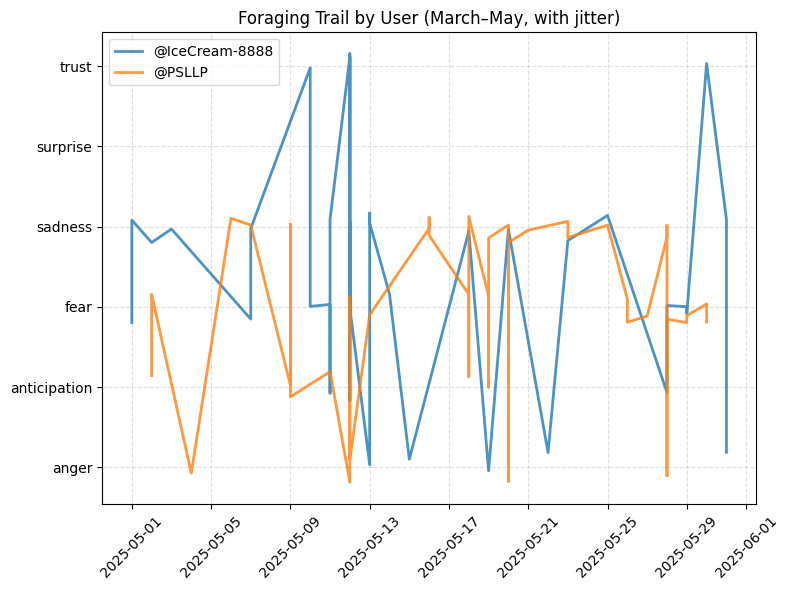

In [169]:
import matplotlib.dates as mdates
import numpy as np

# Filter for March to May (months 3, 4, 5)
filtered_period = df_foraging_trail_community.filter(
    (pl.col("date").dt.month() >= 5) & (pl.col("date").dt.month() <= 5)
)

emotion_order = sorted(filtered_period["emotion"].unique().to_list())
users = ['@IceCream-8888', '@PSLLP']

plt.figure(figsize=(8, 6))
for idx, user in enumerate(users):
    data = filtered_period.filter(pl.col("user") == user)
    dates = data["date"].to_list()
    emotions = data["emotion"].to_list()
    emotion_to_y = {e: i for i, e in enumerate(emotion_order)}
    y_values = [emotion_to_y[e] + np.random.uniform(-0.2, 0.2) for e in emotions]  # jitter
    plt.plot(dates, y_values, label=user, linestyle='-', alpha=0.8, linewidth=2)

plt.yticks(ticks=list(range(len(emotion_order))), labels=emotion_order)
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.title("Foraging Trail by User (March–May, with jitter)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


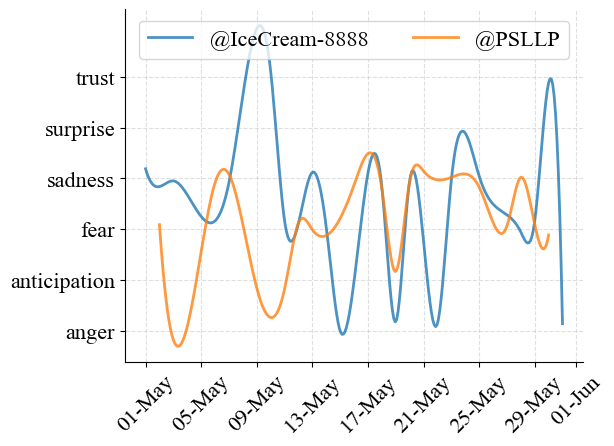

In [208]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"

# Aggregate by date and user: take the most common emotion per day
for idx, user in enumerate(users):
    data = filtered_period.filter(pl.col("user") == user)
    if data.height == 0:
        continue
    # Group by date, take mode of emotion
    agg = (
        data.group_by("date")
        .agg(pl.col("emotion").mode().first().alias("emotion"))
        .sort("date")
    )
    dates = agg["date"].to_list()
    emotions = agg["emotion"].to_list()
    emotion_to_y = {e: i for i, e in enumerate(emotion_order)}
    # Add jitter to y values
    y_values = [emotion_to_y[e] + np.random.uniform(-0.2, 0.2) for e in emotions]

    if len(dates) > 3 and len(set(dates)) == len(dates):
        dates_num = mdates.date2num(dates)
        spline = make_interp_spline(dates_num, y_values, k=3)
        dates_smooth = np.linspace(dates_num.min(), dates_num.max(), 300)
        y_smooth = spline(dates_smooth)
        plt.plot(mdates.num2date(dates_smooth), y_smooth, label=user, linewidth=2, alpha=0.8)
    else:
        plt.plot(dates, y_values, label=user, linewidth=2, alpha=0.8)
    plt.yticks(ticks=list(range(len(emotion_order))), labels=emotion_order, fontsize=16)
    plt.xticks(rotation=45, fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.legend(ncol=len(users), loc='upper center', bbox_to_anchor=(0.5, 1), fontsize=16)

# Show only x and y axis lines
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)

# Change x-ticks to dd-mm format
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))

plt.show()

In [ ]:
# # Build Foraging Graph
# def build_foraging_graph1(tx):
#     query = """
#     // Create FORAGED edges from comment authors
#     MATCH (c:Comment)-[:COMMENT_ON]->(v:Video)
#     WHERE c.authorDisplayName IS NOT NULL AND c.authorDisplayName <> 'NaN'
#     MERGE (u:User {name: c.authorDisplayName})
#     MERGE (u)-[:FORAGED]->(v);
#     """
#     tx.run(query)

# def build_foraging_graph2(tx):
#     query = """
#     // Create FORAGED edges from reply authors
#     MATCH (r:Reply)-[:COMMENT_ON]->(v:Video)
#     WHERE r.authorDisplayName IS NOT NULL AND r.authorDisplayName <> 'NaN'
#     MERGE (u:User {name: r.authorDisplayName})
#     MERGE (u)-[:FORAGED]->(v);
#     """
#     tx.run(query)

# # Insert the foraging graph data
# with driver.session() as session:
#     session.execute_write(build_foraging_graph1)
#     session.execute_write(build_foraging_graph2)

# # Build Foraging Graph with Communities
# def build_foraging_graph_with_communities1(tx):
#     query = """
#     // Create ENGAGED_WITH edges to emotion patches (community)
#     MATCH (c:Comment)-[:COMMENT_ON]->(v:Video)
#     WHERE c.authorDisplayName IS NOT NULL AND v.community IS NOT NULL
#     MERGE (u:User {name: c.authorDisplayName})
#     MERGE (p:Patch {id: v.community})
#     MERGE (u)-[:ENGAGED_WITH]->(p);
#     """
#     tx.run(query)

# def build_foraging_graph_with_communities2(tx):
#     query = """
#     MATCH (r:Reply)-[:COMMENT_ON]->(v:Video)
#     WHERE r.authorDisplayName IS NOT NULL AND v.community IS NOT NULL
#     MERGE (u:User {name: r.authorDisplayName})
#     MERGE (p:Patch {id: v.community})
#     MERGE (u)-[:ENGAGED_WITH]->(p);
#     """
#     tx.run(query)

# # Insert the foraging graph data
# with driver.session() as session:
#     session.execute_write(build_foraging_graph_with_communities1)
#     session.execute_write(build_foraging_graph_with_communities2)